In [2]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('HR Employee Attrition.csv')
print(df)

      Age Attrition     BusinessTravel  DailyRate              Department  \
0      41       Yes      Travel_Rarely       1102                   Sales   
1      49        No  Travel_Frequently        279  Research & Development   
2      37       Yes      Travel_Rarely       1373  Research & Development   
3      33        No  Travel_Frequently       1392  Research & Development   
4      27        No      Travel_Rarely        591  Research & Development   
...   ...       ...                ...        ...                     ...   
1465   36        No  Travel_Frequently        884  Research & Development   
1466   39        No      Travel_Rarely        613  Research & Development   
1467   27        No      Travel_Rarely        155  Research & Development   
1468   49        No  Travel_Frequently       1023                   Sales   
1469   34        No      Travel_Rarely        628  Research & Development   

      DistanceFromHome  Education EducationField  EmployeeCount  \
0       

In [3]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In [4]:
# save cleaned dataset
df.to_csv("hr_cleaned.csv", index=False)

In [5]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  EmployeeCount  \
count  1470.000000  1470.000000       1470.000000  1470.000000         1470.0   
mean     36.923810   802.485714          9.192517     2.912925            1.0   
std       9.135373   403.509100          8.106864     1.024165            0.0   
min      18.000000   102.000000          1.000000     1.000000            1.0   
25%      30.000000   465.000000          2.000000     2.000000            1.0   
50%      36.000000   802.000000          7.000000     3.000000            1.0   
75%      43.000000  1157.000000         14.000000     4.000000            1.0   
max      60.000000  1499.000000         29.000000     5.000000            1.0   

       EmployeeNumber  EnvironmentSatisfaction   HourlyRate  JobInvolvement  \
count     1470.000000              1470.000000  1470.000000     1470.000000   
mean      1024.865306                 2.721769    65.891156        2.729932   
std        602.024335            

In [6]:
print(df.duplicated().sum())

0


In [7]:
print(df.EnvironmentSatisfaction.median())

3.0


In [8]:
print(df.EnvironmentSatisfaction.value_counts())

EnvironmentSatisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64


In [9]:
print(df.DistanceFromHome.value_counts())

DistanceFromHome
2     211
1     208
10     86
9      85
3      84
7      84
8      80
5      65
4      64
6      59
16     32
11     29
24     28
23     27
29     27
15     26
18     26
26     25
25     25
20     25
28     23
19     22
14     21
12     20
17     20
22     19
13     19
21     18
27     12
Name: count, dtype: int64


In [10]:

# total employees
print("\nTotal Employees:")
print(df.shape[0])



Total Employees:
1470


In [11]:

# attrition count
print("\nAttrition")
print(df['Attrition'].value_counts())





Attrition
Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [12]:

# average salary

print(df['MonthlyIncome'].mean())



6502.931292517007


In [13]:

# department wise employee count
print("\nDepartment Wise Employees:")
print(df['Department'].value_counts())



Department Wise Employees:
Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64


In [14]:

# attrition rate
attrition_rate = (
    df[df['Attrition'] == 'Yes'].shape[0]
    / df.shape[0]
) * 100

In [15]:

print("\nAttrition Rate:")
print(round(attrition_rate, 2), "%")




Attrition Rate:
16.12 %


In [16]:
print(df["Gender"].value_counts())

Gender
Male      882
Female    588
Name: count, dtype: int64


In [17]:
print(df["JobSatisfaction"].value_counts())

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64


In [18]:
df=pd.DataFrame(pd.read_csv('hr_cleaned.csv'))

In [19]:

# Map Attrition to numeric for rate calculations (optional, but helpful)
df['Attrition_Num'] = df['Attrition'].map({'Yes': 1, 'No': 0})



In [20]:
pivot1 = pd.pivot_table(df, 
                        values='Attrition_Num', 
                        index='Department', 
                        columns='Gender', 
                        aggfunc='mean') * 100  # Convert to percentage

print(pivot1.round(2))

Gender                  Female   Male
Department                           
Human Resources          30.00  13.95
Research & Development   11.35  15.46
Sales                    20.11  21.01


In [21]:
gp= df.groupby("Attrition").agg({"Gender":"value_counts"})
print(gp)

                  Gender
Attrition Gender        
No        Male       732
          Female     501
Yes       Male       150
          Female      87


In [22]:
gp= df.groupby(["Attrition","Department","Gender"]).agg({"Gender":"count"})
print(gp)

                                         Gender
Attrition Department             Gender        
No        Human Resources        Female      14
                                 Male        37
          Research & Development Female     336
                                 Male       492
          Sales                  Female     151
                                 Male       203
Yes       Human Resources        Female       6
                                 Male         6
          Research & Development Female      43
                                 Male        90
          Sales                  Female      38
                                 Male        54


In [23]:
gp= df.groupby(["Attrition","Gender","Department"]).agg({"DistanceFromHome":"count"},{"age":"max"})
print(gp)
print("\nagemax")
print(df["Age"].max())

                                         DistanceFromHome
Attrition Gender Department                              
No        Female Human Resources                       14
                 Research & Development               336
                 Sales                                151
          Male   Human Resources                       37
                 Research & Development               492
                 Sales                                203
Yes       Female Human Resources                        6
                 Research & Development                43
                 Sales                                 38
          Male   Human Resources                        6
                 Research & Development                90
                 Sales                                 54

agemax
60


In [24]:
gp= df.groupby(["Department","Gender"]).agg({"MonthlyIncome":"mean"})
print(gp)
print("\nmaximum income")
print(df["MonthlyIncome"].max())


                               MonthlyIncome
Department             Gender               
Human Resources        Female    7264.000000
                       Male      6371.023256
Research & Development Female    6513.691293
                       Male      6129.888316
Sales                  Female    6972.126984
                       Male      6949.645914

maximum income
19999


In [25]:
gp= df.groupby(["Attrition","Gender"]).agg({"JobSatisfaction":"count"})
print(gp)

                  JobSatisfaction
Attrition Gender                 
No        Female              501
          Male                732
Yes       Female               87
          Male                150


In [26]:
gp= df.groupby(["Attrition","Gender"]).agg({"OverTime":"count"})
print(gp)

                  OverTime
Attrition Gender          
No        Female       501
          Male         732
Yes       Female        87
          Male         150


In [27]:
gp= df.groupby(["Department","Gender"]).agg({"MonthlyRate":"mean"})
print(gp)
print("\nmaximum rate")
print(df["MonthlyRate"].max())


                                MonthlyRate
Department             Gender              
Human Resources        Female  14410.500000
                       Male    13066.232558
Research & Development Female  14932.350923
                       Male    13863.221649
Sales                  Female  14185.682540
                       Male    14713.439689

maximum rate
26999


graph creation
and visiualization by graphs

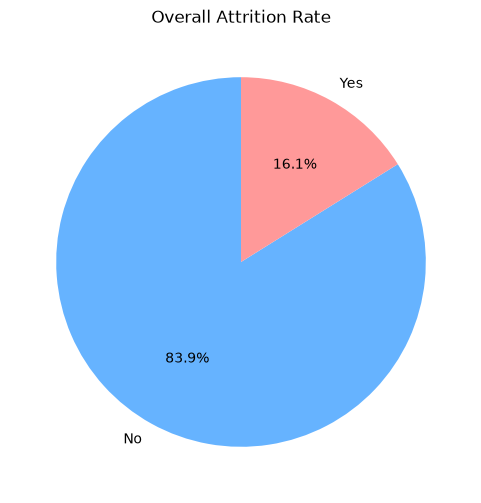

In [28]:
# Pie chart
attrition_counts = df['Attrition'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(attrition_counts, labels=attrition_counts.index, autopct='%1.1f%%', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('Overall Attrition Rate')
plt.show()

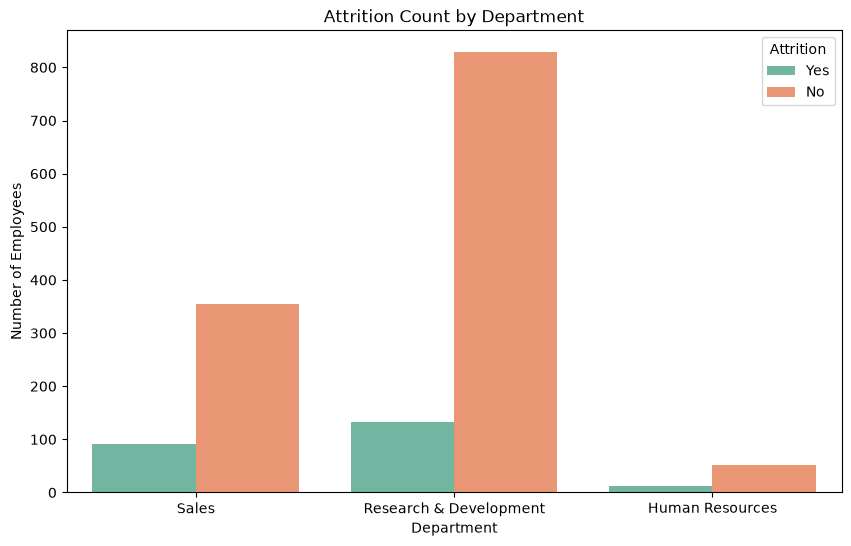

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='Department', hue='Attrition', palette='Set2')
plt.title('Attrition Count by Department')
plt.ylabel('Number of Employees')
plt.show()

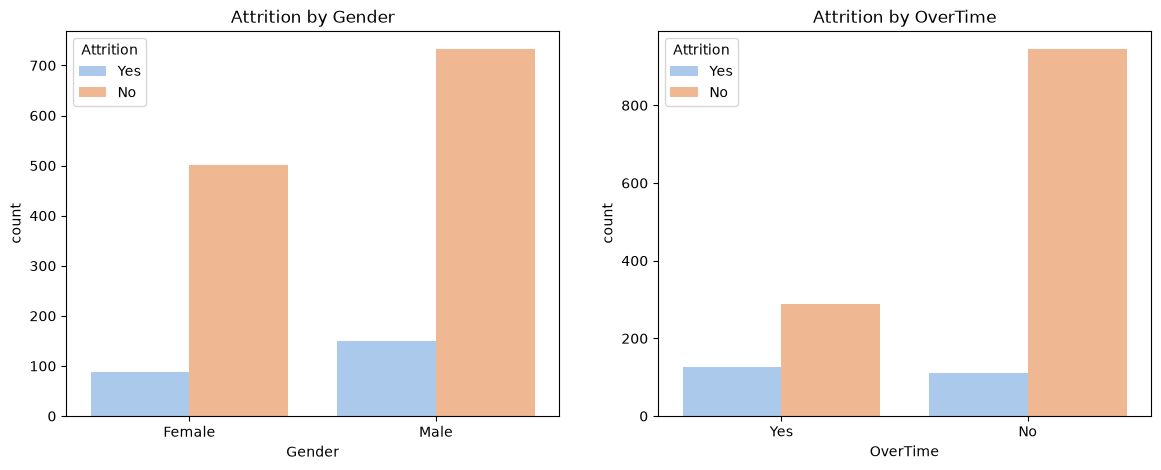

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.countplot(data=df, x='Gender', hue='Attrition', ax=axes[0], palette='pastel')
axes[0].set_title('Attrition by Gender')
sns.countplot(data=df, x='OverTime', hue='Attrition', ax=axes[1], palette='pastel')
axes[1].set_title('Attrition by OverTime')
plt.show()

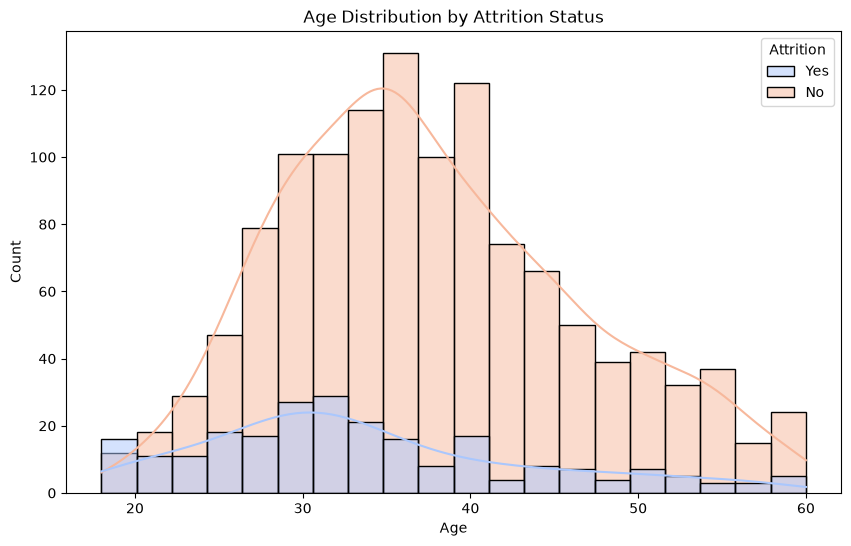

In [31]:
plt.figure(figsize=(10,6))
sns.histplot(data=df, x='Age', hue='Attrition', kde=True, bins=20, palette='coolwarm')
plt.title('Age Distribution by Attrition Status')
plt.show()

C:\Users\prash\AppData\Local\Temp\ipykernel_2856\1050783706.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')


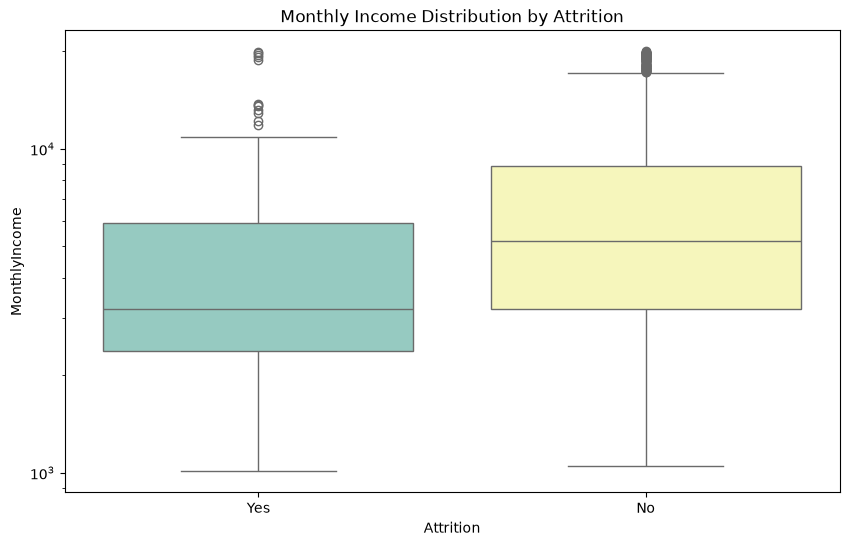

In [32]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title('Monthly Income Distribution by Attrition')
plt.yscale('log')  # because income varies widely
plt.show()

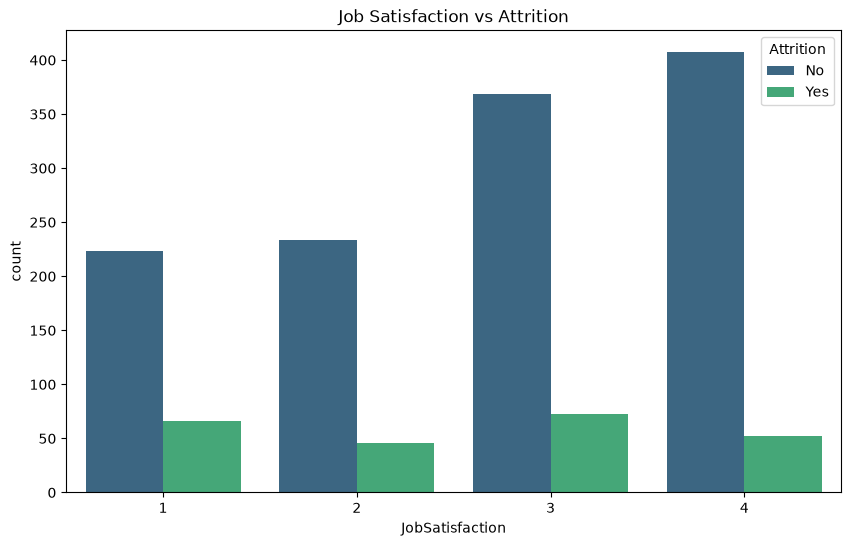

In [33]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='JobSatisfaction', hue='Attrition', palette='viridis')
plt.title('Job Satisfaction vs Attrition')
plt.show()

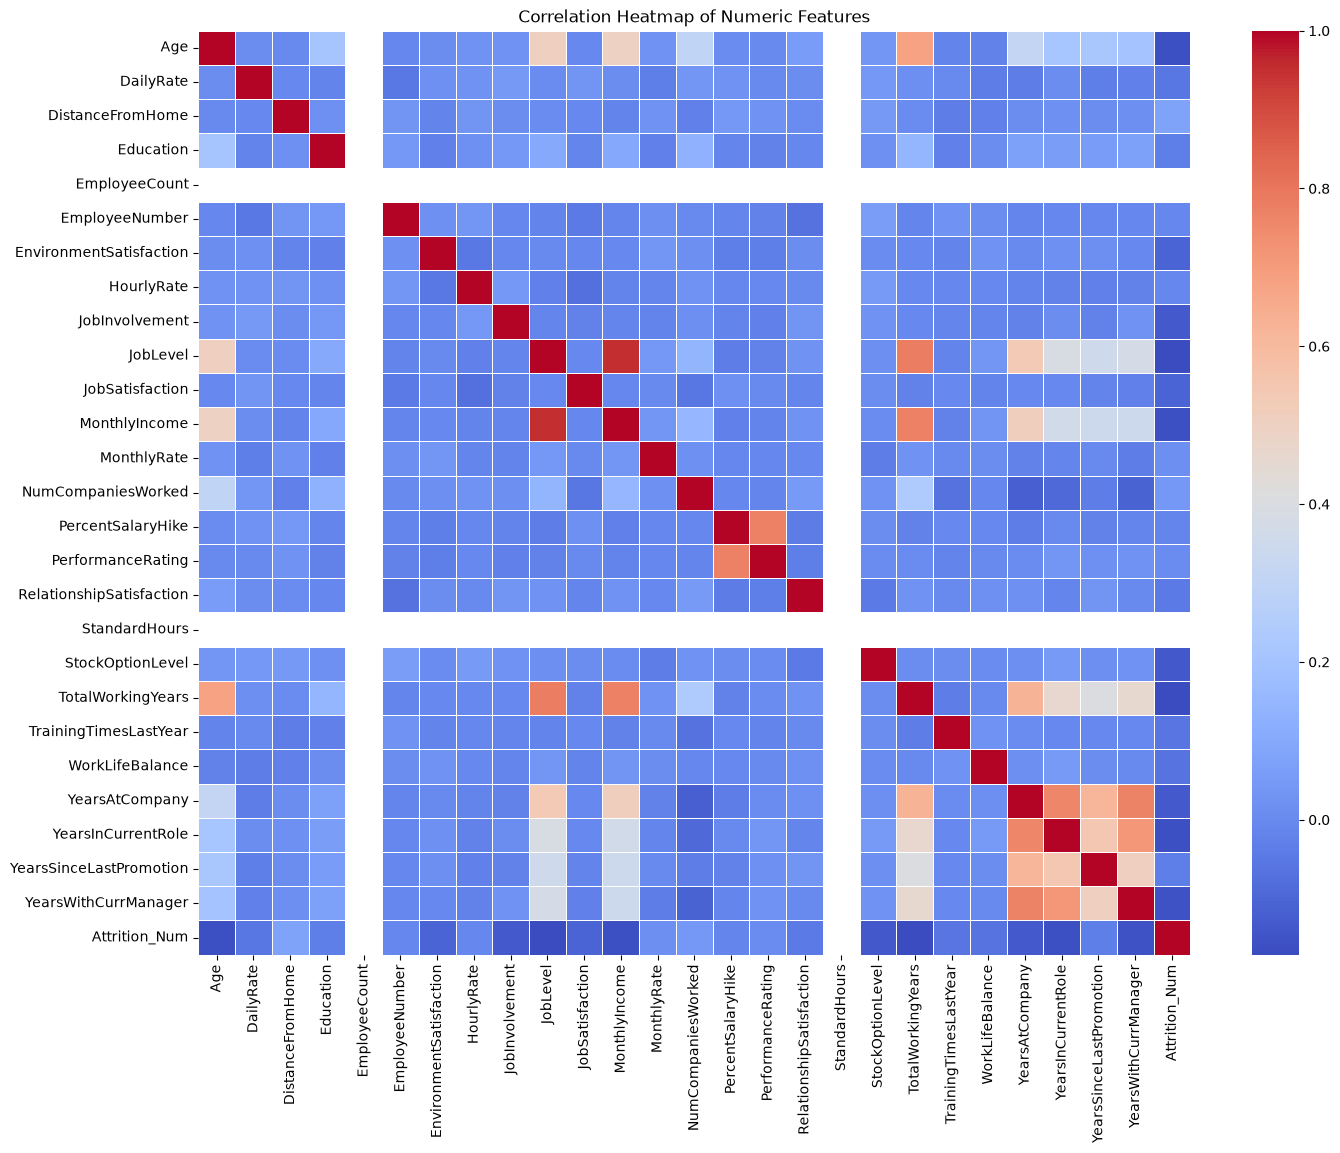

In [34]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
plt.figure(figsize=(16,12))
sns.heatmap(df[numeric_cols].corr(), annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()